# Single RegimeBasis on 1D Burgers
------

Testing PODs on one viscosity file

imports:

In [1]:
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys, pathlib
from datasets import load_dataset
from tqdm.auto import tqdm


sys.path.insert(0, str(pathlib.Path("..").resolve()))
from models.regime_basis import RegimeBasis, FourierRegimeBasis
from models.k_rank_neural_pod import WeightedNeuralPODTrainer, NeuralPODConfig
from models.fourier_neural_pod import FourierNeuralPODTrainer, FourierNeuralPODConfig
from models.classical_neural_pod import ClassicalNeuralPODTrainer, ClassicalNeuralPODConfig
from models.pod import PODTrainer, PODConfig
from utils.plotting import plot_train_history, plot_training_loss, plot_space_time_heatmaps
from utils.datasets import load


if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
DEVICE

'mps'


## Data

We use the 1D Burgers dataset from PDEBench . The Burgers equation combines nonlinear convection with viscous diffusion:

$$u_t + u\,u_x = \nu\,u_{xx},
  \qquad x\in(-1,1),\quad t\in(0,2]$$

The dataset (`Burgers_Nu1.0`) contains solutions for viscosity $\nu = 1.0$, discretized on a uniform grid with $N_x = 1024$ spatial points over $x \in (-1, 1)$ and $N_t = 101$ time steps over $t \in (0, 2)$. Each of the 9500 training samples corresponds to a distinct random initial condition. 

Data is stored in HDF5 format with shape `(N, Nt, Nx, 1)`, along with coordinate arrays `x-coordinate` and `t-coordinate`


Dataset downloading:

In [2]:
data = load("Burgers_Nu0.004")

Look at the data:

In [3]:
data

{'t-coordinate': array([0.        , 0.00784314, 0.01568628, 0.02352941, 0.03137255,
        0.03921569, 0.04705882, 0.05490196, 0.0627451 , 0.07058824,
        0.07843138, 0.08627451, 0.09411765, 0.10196079, 0.10980392,
        0.11764706, 0.1254902 , 0.13333334, 0.14117648, 0.14901961,
        0.15686275, 0.16470589, 0.17254902, 0.18039216, 0.1882353 ,
        0.19607843, 0.20392157, 0.21176471, 0.21960784, 0.22745098,
        0.23529412, 0.24313726, 0.2509804 , 0.25882354, 0.26666668,
        0.27450982, 0.28235295, 0.2901961 , 0.29803923, 0.30588236,
        0.3137255 , 0.32156864, 0.32941177, 0.3372549 , 0.34509805,
        0.3529412 , 0.36078432, 0.36862746, 0.3764706 , 0.38431373,
        0.39215687, 0.4       , 0.40784314, 0.41568628, 0.42352942,
        0.43137255, 0.4392157 , 0.44705883, 0.45490196, 0.4627451 ,
        0.47058824, 0.47843137, 0.4862745 , 0.49411765, 0.5019608 ,
        0.50980395, 0.5176471 , 0.5254902 , 0.53333336, 0.5411765 ,
        0.54901963, 0.5568628 , 

Extracting data:

In [4]:
tensor = data["tensor"]    # (N, Nt, Nx, 1)
x = data["x-coordinate"]   # (Nx,)
t = data["t-coordinate"]   # (Nt,)
u = tensor[:, :, :, 0]     # (N, Nt, Nx)
 
N, Nt, Nx = u.shape
print(f"N={N}, Nt={Nt}, Nx={Nx},  x: [{x[0]:.2f}, {x[-1]:.2f}],  t: [{t[0]:.2f}, {t[-1]:.2f}]")

N=9500, Nt=256, Nx=101,  x: [-1.00, 1.00],  t: [0.00, 2.00]


visualization:

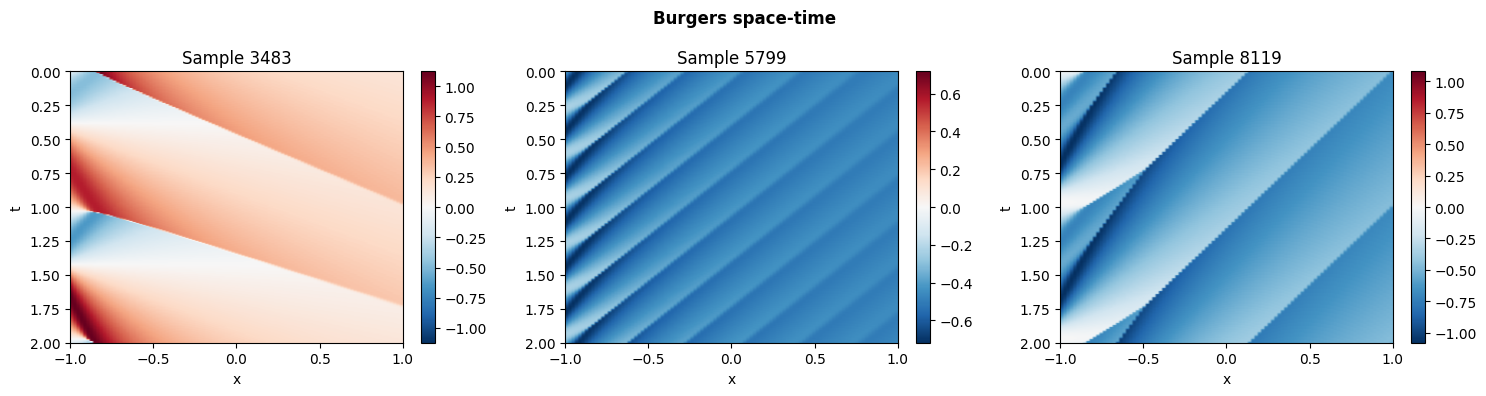

In [5]:
samples = np.random.choice(N, size=3, replace=False)
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, si in zip(axes, samples):
    vmax = np.abs(u[si]).max()
    im = ax.imshow(
        u[si], aspect="auto",
        extent=[x[0], x[-1], t[-1], t[0]],
        cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    )
    ax.set_title(f"Sample {si}")
    ax.set_xlabel("x"); ax.set_ylabel("t")
    plt.colorbar(im, ax=ax, fraction=0.046)
 
fig.suptitle("Burgers space-time", fontweight="bold")
fig.tight_layout()
plt.show()

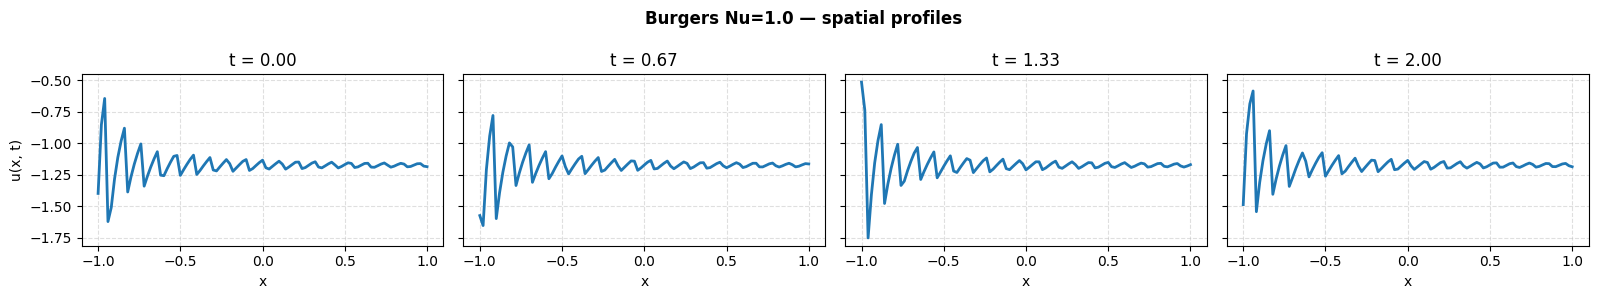

In [6]:
t_ids = [0, Nt // 3, 2 * Nt // 3, Nt - 1]
 
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for ax, ti in zip(axes, t_ids):
    ax.plot(x, u[0, ti], lw=2)
    ax.set_title(f"t = {t[ti]:.2f}")
    ax.set_xlabel("x")
    ax.grid(True, ls="--", alpha=0.4)
 
axes[0].set_ylabel("u(x, t)")
fig.suptitle("Burgers Nu=1.0 — spatial profiles", fontweight="bold")
fig.tight_layout()
plt.show()

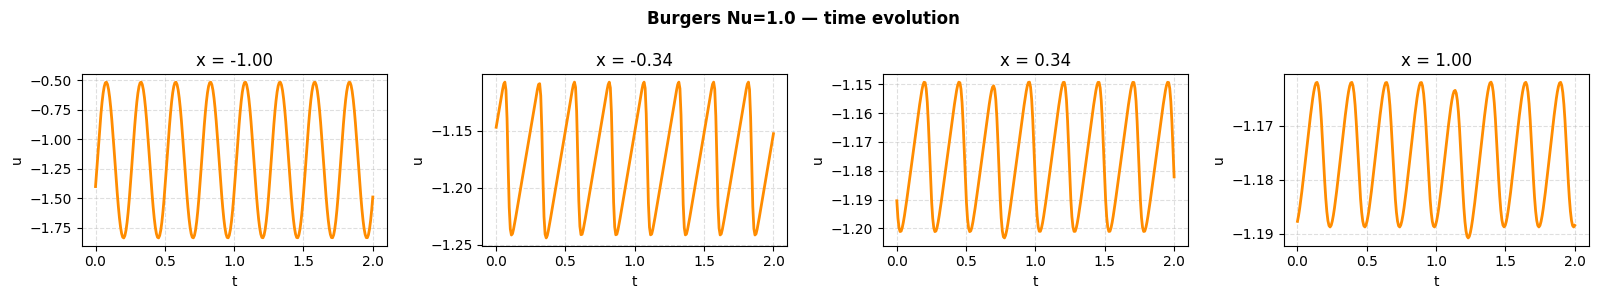

In [7]:
x_ids = [0, Nx // 3, 2 * Nx // 3, Nx - 1]
 
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, xi in zip(axes, x_ids):
    ax.plot(t, u[0, :, xi], lw=2, color="darkorange")
    ax.set_title(f"x = {x[xi]:.2f}")
    ax.set_xlabel("t"); ax.set_ylabel("u")
    ax.grid(True, ls="--", alpha=0.4)
 
fig.suptitle("Burgers Nu=1.0 — time evolution", fontweight="bold")
fig.tight_layout()
plt.show()

## Training

Take 64 samples, downsample x by 8x (1024 -> 128), drop channel dim:

In [8]:
tensor = data["tensor"][:64, :, ::16, 0] 
x_np  = data["x-coordinate"][::16]
t_np = data["t-coordinate"]
N, Nt, Nx = tensor.shape
NU = 1.0

In [9]:
#tensor = data["tensor"][:, :, :, 0]
#x_np   = data["x-coordinate"][:]
#t_np   = data["t-coordinate"]
#N, Nt, Nx = tensor.shape
#NU = 1.0

Each (sample, timestep) pair becomes one snapshot:

In [10]:
s = torch.tensor(tensor.reshape(-1, Nx), dtype=torch.float32)
t = torch.tensor(np.tile(t_np, N), dtype=torch.float32)
x = torch.tensor(x_np[:, None], dtype=torch.float32)
kappa = torch.full((len(s), 1), NU, dtype=torch.float32)
gamma = torch.ones(len(s), dtype=torch.float32) / len(s)

s, t, x, kappa, gamma = [v.to(DEVICE) for v in [s, t, x, kappa, gamma]]
print(f"s={s.shape}, t={t.shape}, x={x.shape}")

s=torch.Size([16384, 7]), t=torch.Size([16384]), x=torch.Size([7, 1])


## Classical NeuralPOD

In [11]:
Ny = x.shape[0]
N = s.shape[0]

In [12]:
N_samples = 5    # 5  initial conditions
tensor = data["tensor"][:N_samples, :, :, 0]  # (5, 256, 1024) - og resolution
x_np = data["x-coordinate"][:]                # (1024,)
t_np = data["t-coordinate"]                   # (256,)

N, Nt, Nx = tensor.shape  # N=5, Nt=256, Nx=1024

s = torch.tensor(tensor.reshape(-1, Nx), dtype=torch.float32)  # (1280, 1024)
t = torch.tensor(np.tile(t_np, N), dtype=torch.float32)         # (1280,)
x = torch.tensor(x_np[:, None], dtype=torch.float32)            # (1024, 1)
s, t, x = [v.to(DEVICE) for v in [s, t, x]]
print(f"s={s.shape}, t={t.shape}, x={x.shape}")

s=torch.Size([1280, 101]), t=torch.Size([1280]), x=torch.Size([101, 1])


Config:

In [13]:
cfg = ClassicalNeuralPODConfig(
    tol=1e-3,
    lr=5e-4,
    max_modes=5,
    n_epochs=100,
    batch_size=32,
    log_every=10,
    hidden_dim=64,
    n_layers=2,
)

In [14]:
trainer_classical = ClassicalNeuralPODTrainer(cfg)

In [15]:
history = trainer_classical.train(s, x, t)

# Predictions
s_pred = trainer_classical.predict(x, t).cpu().detach().numpy()
s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_pred) / np.linalg.norm(s_np)


Classical NeuralPOD (Greedy Training)
Data: N=1280 snapshots, Ny=101 spatial points, d_x=1
Tolerance (absolute): 4.713619e-04

Mode 1: residual_norm = 4.713619e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  after mode: residual_norm = 4.683158e-01

Mode 2: residual_norm = 4.683158e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  after mode: residual_norm = 4.680215e-01

Mode 3: residual_norm = 4.680215e-01


...

  after mode: residual_norm = 4.680044e-01

Mode 4: residual_norm = 4.680044e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  after mode: residual_norm = 4.680043e-01

Mode 5: residual_norm = 4.680043e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  after mode: residual_norm = 4.680042e-01

Training complete: 5 modes trained




Trained 5 modes
Relative L2 error: 0.9964



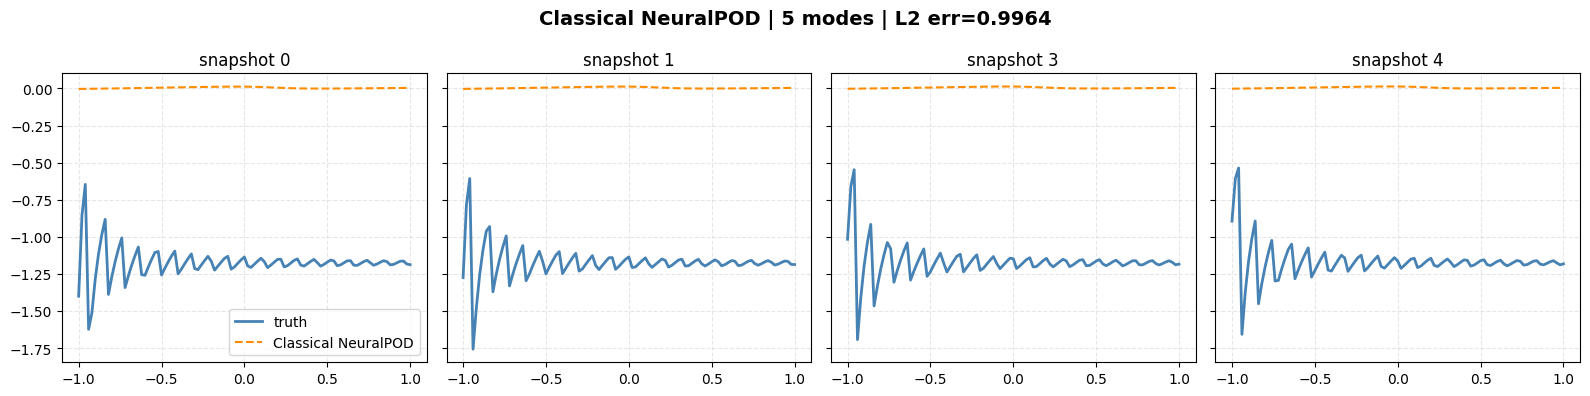

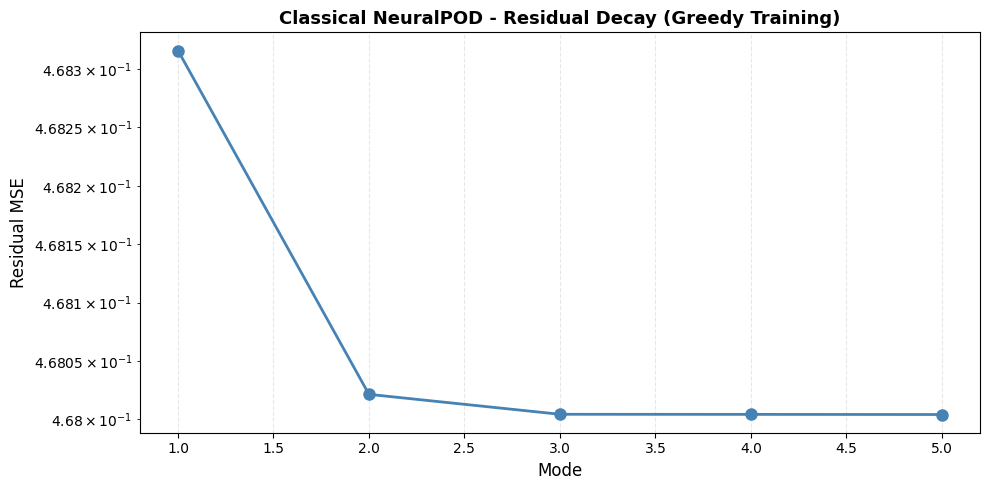

In [16]:
print(f"\nTrained {len(trainer_classical.modes)} modes")
print(f"Relative L2 error: {rel_err:.4f}\n")


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, idx in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[idx], lw=2, label="truth", color="steelblue")
    ax.plot(x.cpu().numpy(), s_pred[idx], lw=1.5, ls="--", label="Classical NeuralPOD", color="darkorange")
    ax.set_title(f"snapshot {idx}")
    ax.grid(True, ls="--", alpha=0.3)
axes[0].legend()
plt.suptitle(f"Classical NeuralPOD | {len(trainer_classical.modes)} modes | L2 err={rel_err:.4f}", 
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
if history.residual_norms:
    ax.semilogy(range(1, len(history.residual_norms)+1), history.residual_norms, 
                'o-', linewidth=2, markersize=8, color='steelblue')
    ax.set_xlabel('Mode', fontsize=12)
    ax.set_ylabel('Residual MSE', fontsize=12)
    ax.set_title('Classical NeuralPOD - Residual Decay (Greedy Training)', fontsize=13, fontweight='bold')
    ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

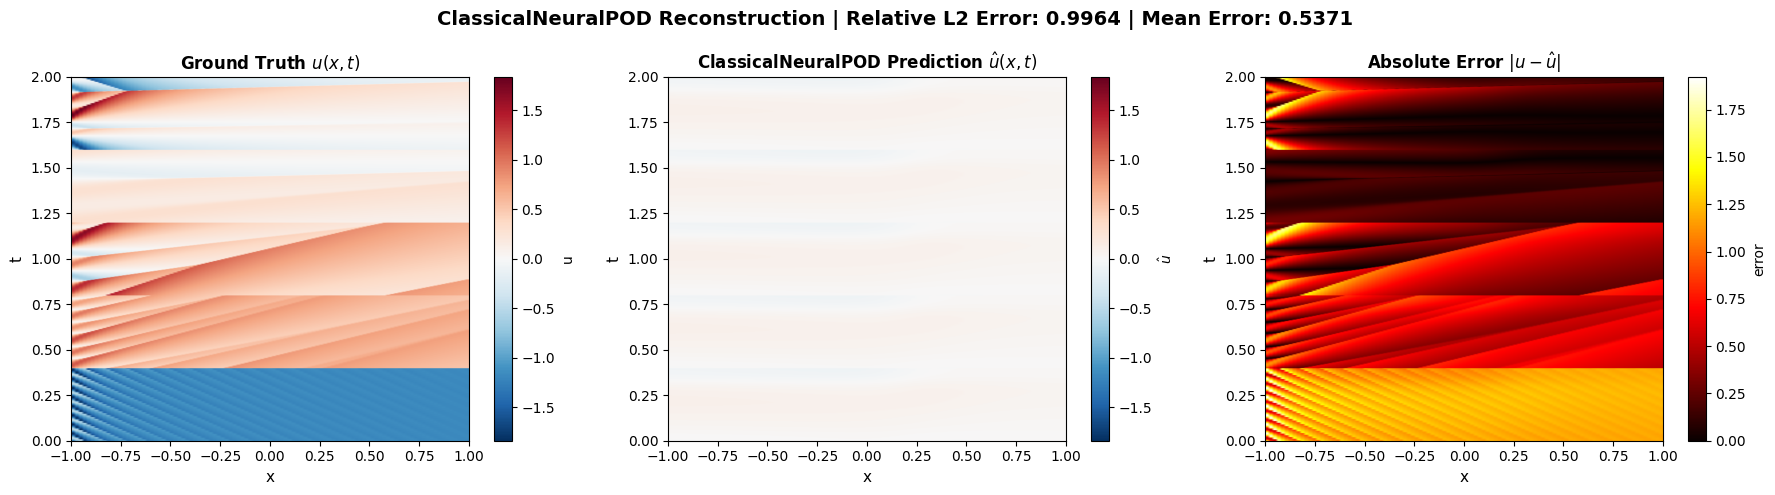

In [17]:
fig = plot_space_time_heatmaps(trainer_classical, s, x, t, "ClassicalNeuralPOD")
plt.show()

## Simultaneous Neural POD

Joint Training Approach

All components trained simultaneously:

$$\hat{s}(x, t, \kappa) = {\mu(x, \kappa)} + \underbrace{\sum_{k=1}^{K} a_k(t, \kappa) \phi_k(x)}_{\text{K modes jointly}}$$

Combined Loss:
$$\mathcal{L}{\text{total}} = w_{\text{data}} \cdot \text{MSE}(\hat{s}, s) + w_{\text{basis}} \cdot \left(|\Phi|_{\text{rms}} - 1\right)^2$$

Reciprocal Weighting (auto-balance):
$$w_{\text{data}} = \frac{1}{L_{\text{data}}^{(0)}}, \quad w_{\text{basis}} = \frac{1}{L_{\text{basis}}^{(0)}}$$

Basis Orthonormality Soft Constraint:
$$L_{\text{basis}} = \left(\sqrt{\frac{|\Phi|_F^2}{N_y \times K}} - 1\right)^2$$

where $\mu$, $a_k$, $\phi_k$ all optimized end-to-end via gradient descent.

init basis:

In [18]:
quad_w = torch.full((Nx,), 1.0/Nx, dtype=torch.float32, device=DEVICE)
basis   = RegimeBasis(d_x=1, d_kappa=1, quad_weights=quad_w, K=8, hidden_dim=64).to(DEVICE)
gamma = torch.ones(len(s), dtype=torch.float32) / len(s)
gamma = gamma.to(DEVICE)

data scale:

In [19]:
s_norm = basis._weighted_norm_sq(s, gamma).item()
print(f"Initial weighted norm of s: {s_norm:.4f}")

Initial weighted norm of s: 0.4714


init trainer:

In [20]:
Ny = x.shape[0]
N = s.shape[0] 


quad_w = torch.full((Ny,), 1.0/Ny, dtype=torch.float32, device=DEVICE)
basis_authors = RegimeBasis(d_x=1, d_kappa=1, quad_weights=quad_w, K=8, hidden_dim=64).to(DEVICE)

cfg = NeuralPODConfig(
    lr=5e-4,
    K=8,
    n_epochs=300,
    batch_size=32,
    grad_clip_norm=1.0,
    log_every=5,
    lambda_basis=1.0
)

trainer_authors = WeightedNeuralPODTrainer(basis_authors, cfg)


Training:

In [21]:
history_authors = trainer_authors.train(s, x, t, kappa, gamma)


Weighted Joint Neural POD Training
Data: s=(1280, 101), x=(101, 1)
Config: K=8, n_epochs=300, batch_size=32
Optimizer: lr=0.0005, grad_clip=1.0


training:   0%|          | 0/300 [00:00<?, ?it/s]

Weight initialization:
  L_data = 5.3144e-01, w_data = 1.8817e+00
  L_basis = 5.8278e-01, w_basis = 1.7159e+00

Training complete: 300 epochs
Final loss: 1.5318e+00



Results

Visualization:

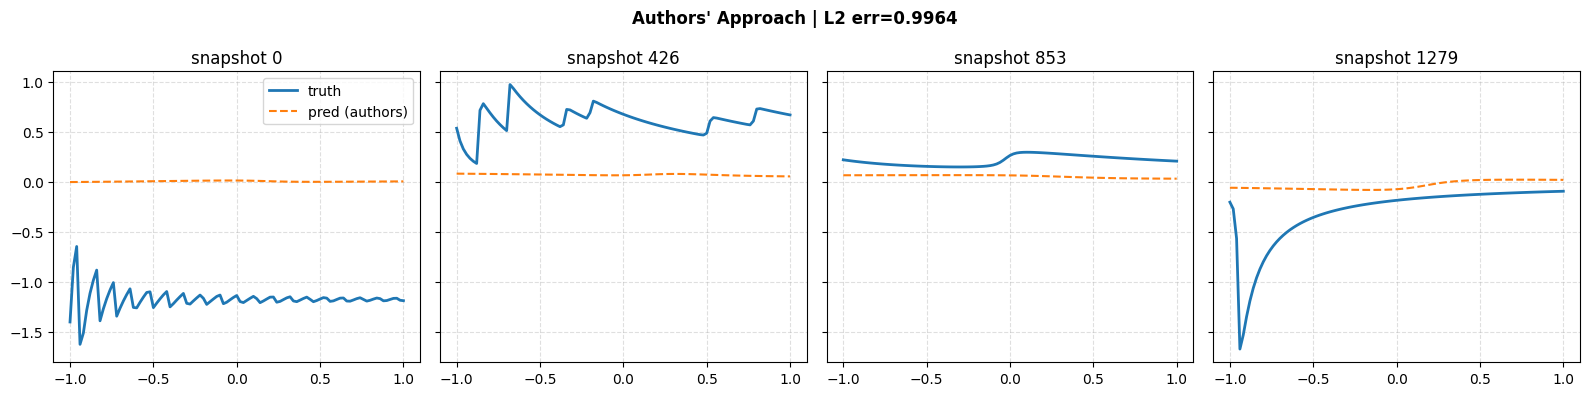

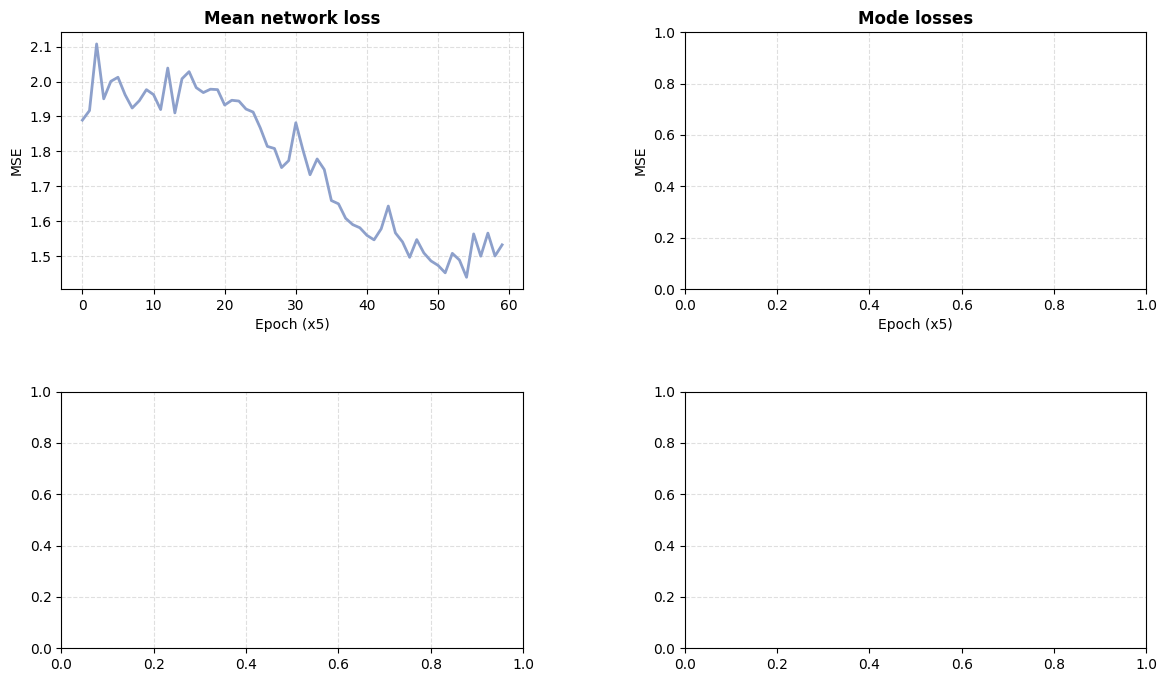

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_pred[ti], lw=1.5, ls="--", label="pred (authors)")
    ax.set_title(f"snapshot {ti}")
    ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"Authors' Approach | L2 err={rel_err:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

plot_train_history(trainer_authors)
plt.show()

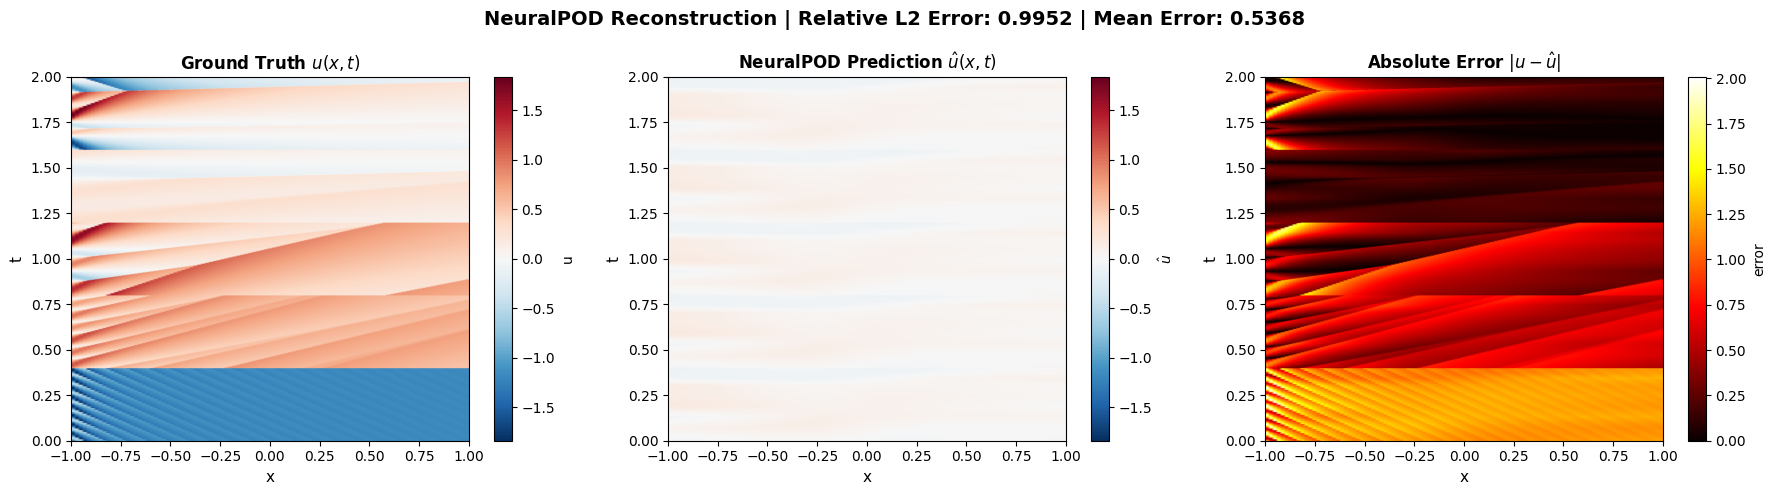

In [23]:
plot_space_time_heatmaps(basis_authors, s, x, t)
plt.show()

## Neural Fourier POD

**Reconstruction:**
$$\hat{s}(x) = \mu(x) + \sum_{p=1}^{P} \Phi_p(x) \cdot \lambda_p$$

**Spatial Basis (Random Fourier Features):**
$$\Phi_p(x) = \text{MLP}\left([\sin(2\pi Bx), \cos(2\pi Bx)]\right), \quad B \in \mathbb{R}^{M \times d_x} \text{ fixed random}$$

**Temporal Coefficients:**
$$\lambda_p = [\lambda_{p,1}, ..., \lambda_{p,N}] \in \mathbb{R}^N \text{ (learnable)}$$

**Mode Prediction:**
$$\text{pred}_p(x) = \lambda_p \otimes \Phi_p(x) \in \mathbb{R}^{N \times N_y}$$

**Greedy Training (with deflation):**
$$
\text{For } p = 1, ..., P:
\begin{cases}
r^{(p)} = s - \left(\mu + \sum_{q<p} \text{pred}_q\right) \\
\min_{\Phi_p, \lambda_p} \|\lambda_p \otimes \Phi_p(x) - r^{(p)}\|_F^2 \\
\text{Stop if } \|r^{(p)}\| < \epsilon \cdot \|s\| \text{ or } p = P_{\max}
\end{cases}
$$

**Optimization:**
- Adam: $\text{lr}_{\Phi} = 5\times10^{-4}$, $\text{lr}_{\lambda} = 10^{-2}$ (separate)
- OneCycleLR scheduler, gradient clipping: $\|\nabla\| \leq 1.0$

In [24]:
N = s.shape[0]
Ny = x.shape[0]

new basis:

In [25]:
quad_w = torch.full((Ny,), 1.0/Ny, dtype=torch.float32, device=DEVICE)
basis = FourierRegimeBasis(d_x=1, M=N, quad_weights=quad_w).to(DEVICE)

trainer config:

In [26]:
cfg = FourierNeuralPODConfig(n_epochs_mean = 500, n_epochs_mode = 300,
                             max_modes = 8)
trainer_fourier = FourierNeuralPODTrainer(basis, cfg)

training:

In [27]:
history = trainer_fourier.train(s, x, t, kappa, gamma)

Fourier NeuralPOD | N=1280, Ny=101 | max_modes=8


mean:   0%|          | 0/500 [00:00<?, ?it/s]

mode 1:   0%|          | 0/300 [00:00<?, ?it/s]

  mode 1: weighted_res=3.9686e-02


mode 2:   0%|          | 0/300 [00:00<?, ?it/s]

...

  mode 6: weighted_res=1.1307e-02


mode 7:   0%|          | 0/300 [00:00<?, ?it/s]

  mode 7: weighted_res=1.0451e-02


mode 8:   0%|          | 0/300 [00:00<?, ?it/s]

  mode 8: weighted_res=9.2680e-03
  done: 8 modes



Error:

In [28]:
basis.eval()
with torch.no_grad():
    s_hat = basis(x, t, kappa).cpu().numpy()

s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_hat) / np.linalg.norm(s_np)
print(f"Relative L2 error: {rel_err:.4f}")

Relative L2 error: 0.1402


visualization:

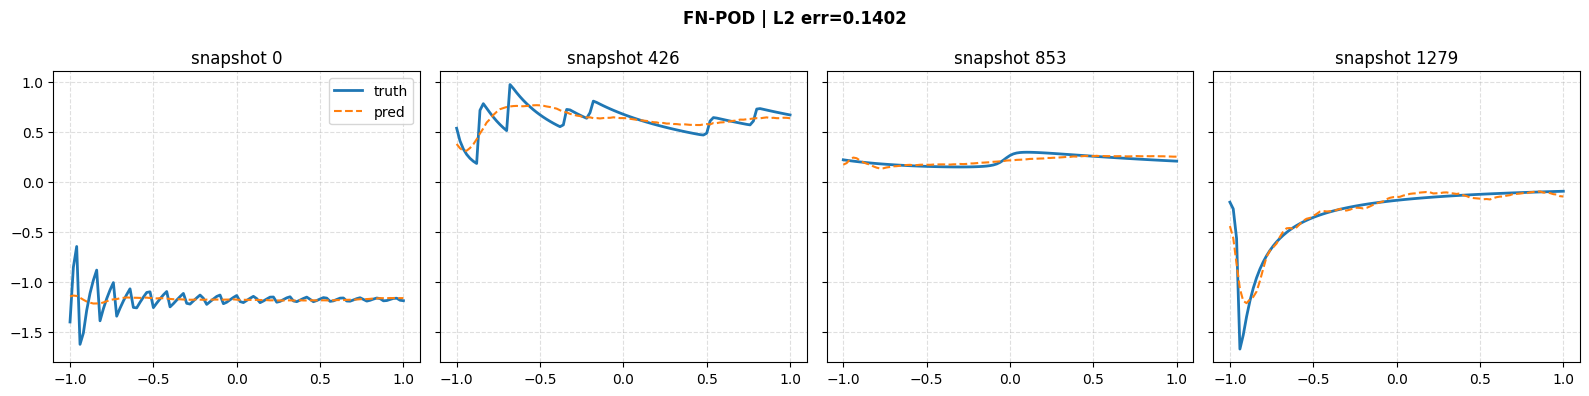

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_hat[ti], lw=1.5, ls="--", label="pred")
    ax.set_title(f"snapshot {ti}"); ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"FN-POD | L2 err={rel_err:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

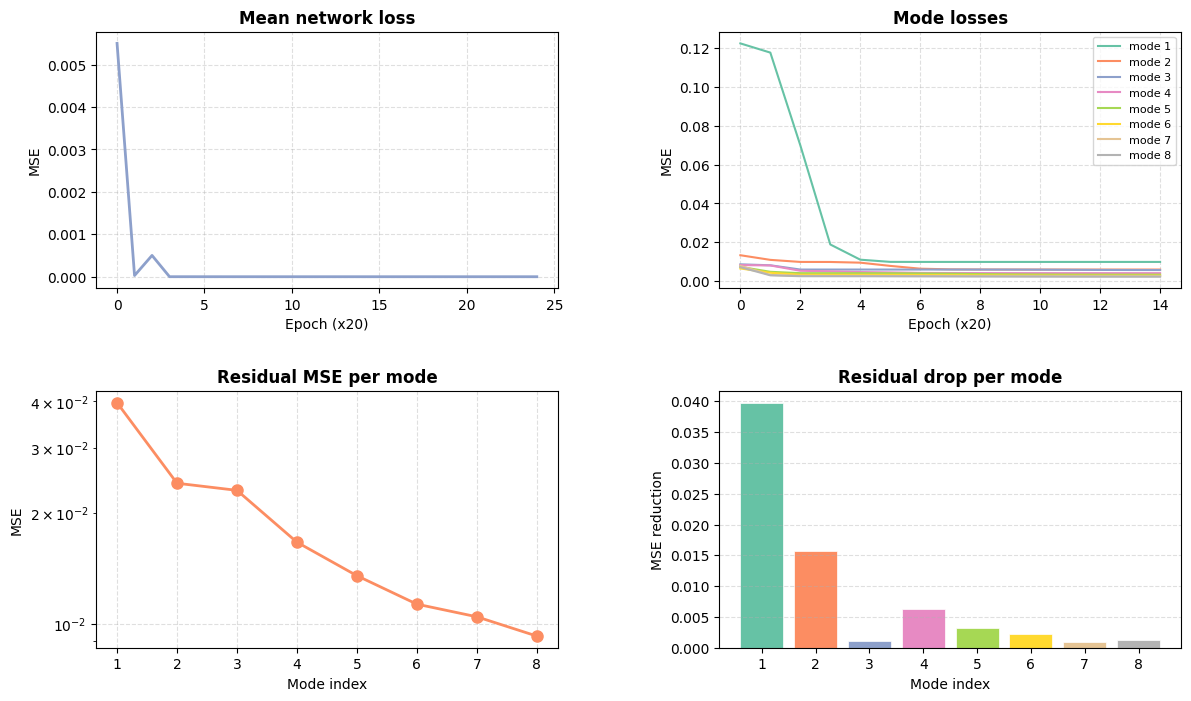

In [30]:
plot_train_history(trainer_fourier)
plt.show()

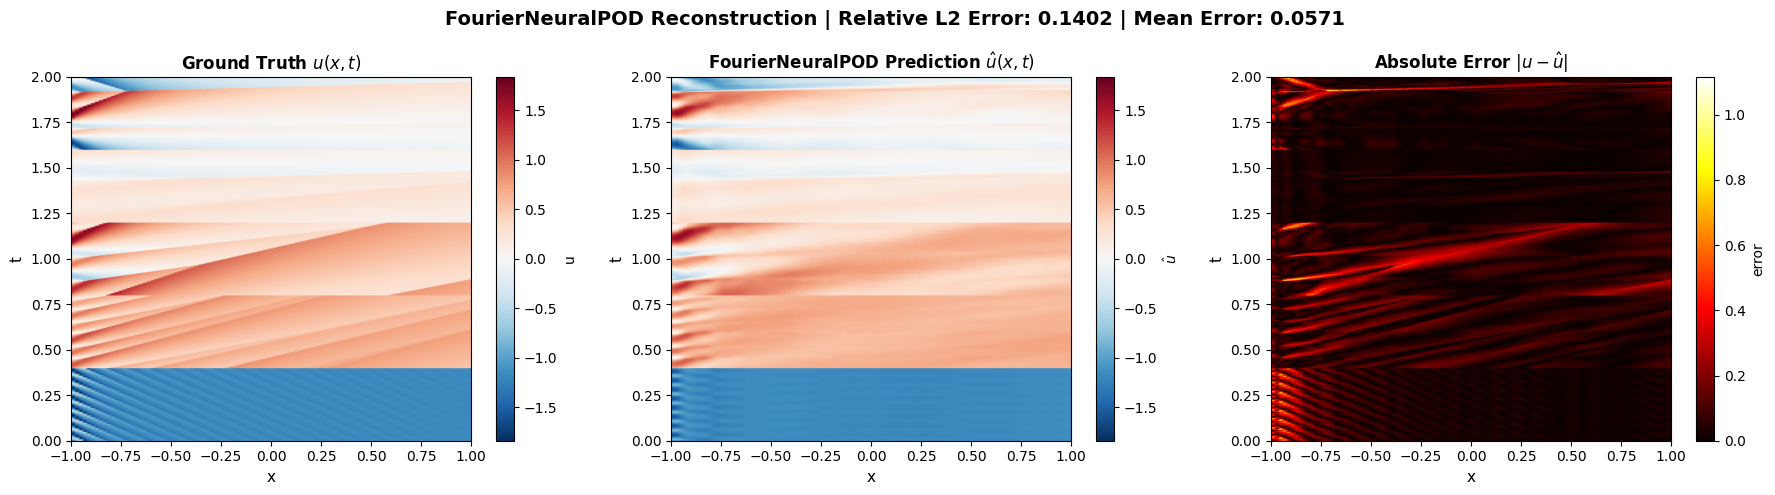

In [31]:
fig = plot_space_time_heatmaps(trainer_fourier, s, x, t, "FourierNeuralPOD")
plt.show()

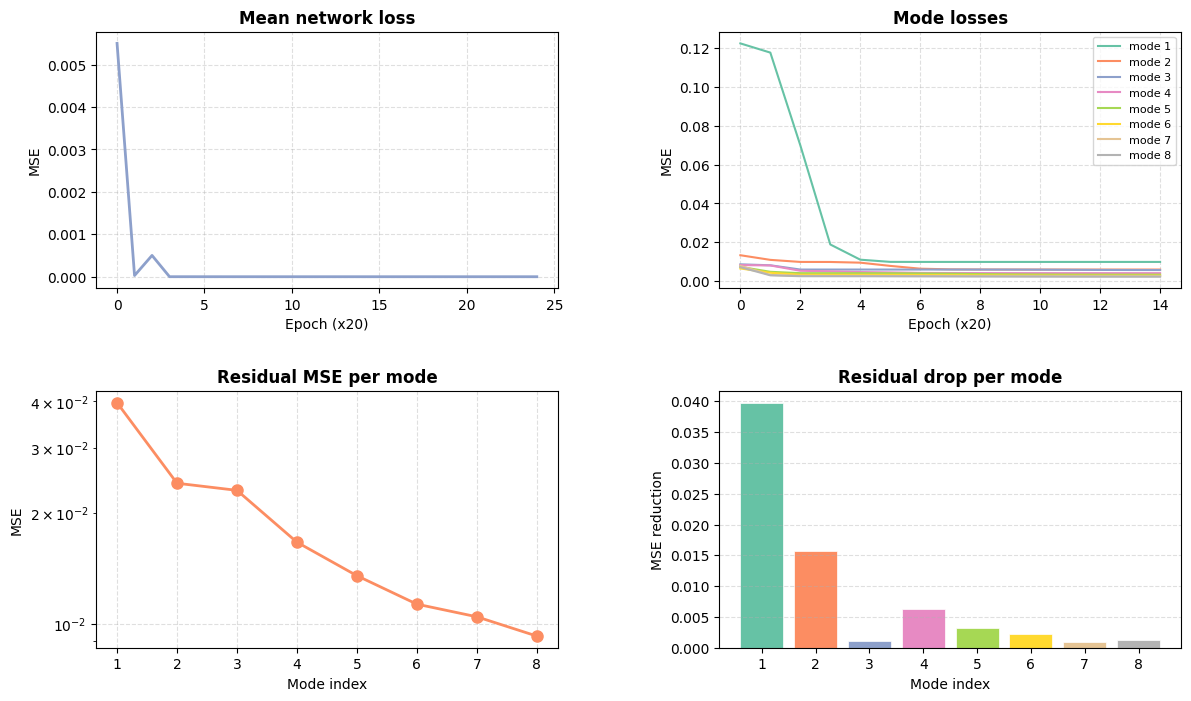

In [32]:
plot_train_history(trainer_fourier)
plt.show()

## Classical POD (SVD)

Classical SVD

Given snapshot matrix $S \in \mathbb{R}^{N \times N_y}$ and responsibility weights $\gamma \in \mathbb{R}^N$:

1. **Weighted mean**: $\bar{s}(x) = \sum_i \gamma_i s^{(i)}(x)$

2. **Center**: $\tilde{S} = S - \mathbf{1}\bar{s}^\top$

3. **Weighted SVD**: scale rows by $\sqrt{\gamma_i}$, then SVD:
$$S_w = \mathrm{diag}(\sqrt{\gamma})\,\tilde{S} = U\Sigma V^\top$$
Modes $V_{:,1:P}$ are optimal under the $\gamma$-weighted $L^2$ norm.

4. **Select $P$ modes** by variance threshold: $\sum_{k=1}^P \sigma_k^2 / \sum_k \sigma_k^2 \geq \tau$

5. **Coefficients**: $\alpha^{(i)} = \tilde{s}^{(i)} \cdot V_{:,1:P}$

6. **Reconstruction**: $\hat{s}^{(i)}(x) = \bar{s}(x) + \sum_{p=1}^P \alpha^{(i)}_p \phi_p(x)$


config:

In [33]:
cfg_pod = PODConfig(
    max_modes=5,
    tol=0.9999,
)
trainer_pod = PODTrainer(cfg_pod)

history_pod = trainer_pod.train(s, x, t, kappa, gamma)

POD | N=1280, Ny=101 | max_modes=5, tol=0.9999
  P=5 modes (99.99% variance threshold, needed 73)
  mode  1: sigma=6.5930e+00  cumvar=91.56%  res_mse=3.9686e-02
  mode  2: sigma=1.2583e+00  cumvar=94.89%  res_mse=2.4009e-02
  mode  3: sigma=8.6368e-01  cumvar=96.46%  res_mse=1.6623e-02
  mode  4: sigma=6.1035e-01  cumvar=97.25%  res_mse=1.2935e-02
  mode  5: sigma=5.1035e-01  cumvar=97.80%  res_mse=1.0356e-02
  done: final res_mse=1.0356e-02


training:

In [34]:
history_pod = trainer_pod.train(s, x, t, kappa, gamma)

POD | N=1280, Ny=101 | max_modes=5, tol=0.9999
  P=5 modes (99.99% variance threshold, needed 73)
  mode  1: sigma=6.5930e+00  cumvar=91.56%  res_mse=3.9686e-02
  mode  2: sigma=1.2583e+00  cumvar=94.89%  res_mse=2.4009e-02
  mode  3: sigma=8.6368e-01  cumvar=96.46%  res_mse=1.6623e-02
  mode  4: sigma=6.1035e-01  cumvar=97.25%  res_mse=1.2935e-02
  mode  5: sigma=5.1035e-01  cumvar=97.80%  res_mse=1.0356e-02
  done: final res_mse=1.0356e-02


results:

In [35]:
trainer_pod.basis.eval()
with torch.no_grad():
    s_pred_pod = trainer_pod.basis(x, t, kappa).cpu().numpy()
    
s_np = s.cpu().numpy()
rel_err_pod = np.linalg.norm(s_np - s_pred_pod) / np.linalg.norm(s_np)
print(f"Relative L2 error: {rel_err_pod:.4f}")

Relative L2 error: 0.1482


visualization:

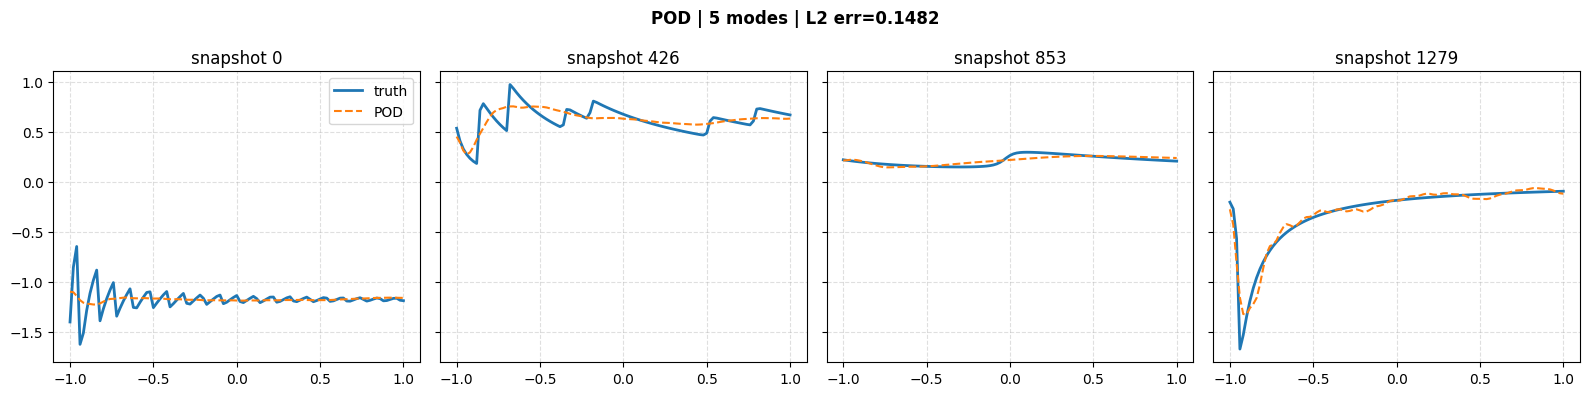

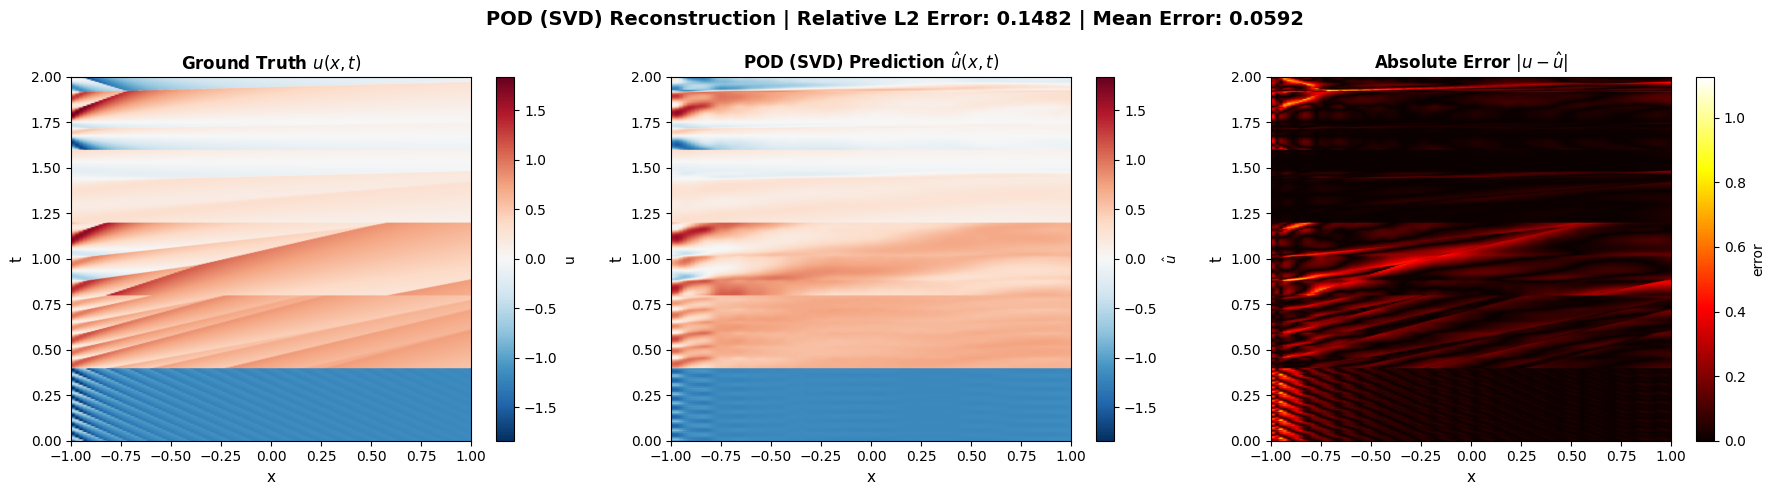

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_pred_pod[ti], lw=1.5, ls="--", label="POD")
    ax.set_title(f"snapshot {ti}")
    ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"POD | {trainer_pod.num_modes} modes | L2 err={rel_err_pod:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

fig = plot_space_time_heatmaps(trainer_pod, s, x, t, "POD (SVD)")
plt.show()

Singular value decay:

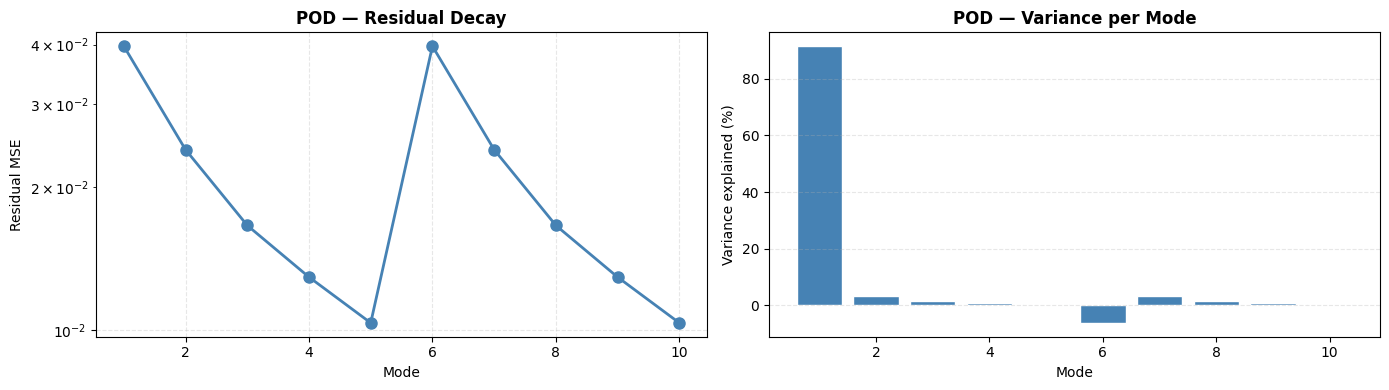

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(
    range(1, len(history_pod.residual_norms)+1),
    history_pod.residual_norms,
    'o-', lw=2, ms=8, color='steelblue'
)
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Residual MSE')
axes[0].set_title('POD — Residual Decay', fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.3)

# Variance expl
cumvar = np.cumsum([history_pod.mean_loss[0] - history_pod.residual_norms[0]] +
                   [history_pod.residual_norms[i-1] - history_pod.residual_norms[i]
                    for i in range(1, len(history_pod.residual_norms))])
cumvar_pct = cumvar / history_pod.mean_loss[0] * 100

axes[1].bar(range(1, len(cumvar_pct)+1), np.diff([0, *cumvar_pct]),
            color='steelblue', edgecolor='white')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('POD — Variance per Mode', fontweight='bold')
axes[1].grid(True, ls='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()